In [1]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.metrics import silhouette_score,davies_bouldin_score
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
data = pd.read_csv('final_features.csv')
data.head()

,original_index,track_id,song_name,artist,genre,chorus_ratio,syllable_density,sentiment_score,flesch_kincaid_readability,lsa_component_1,lsa_component_2,lsa_component_3,lsa_component_4,lsa_component_5,lsa_component_6,lsa_component_7,lsa_component_8,lsa_component_9,lsa_component_10
0,17623,Pop_00001,A Child Is Born,Rihanna,Pop,0.7317,1.6751,0.9985,-213.015852,0.181620,-0.032062,0.074830,-0.052017,0.024681,0.013611,-0.108253,-0.050807,0.016758,-0.059504
1,17624,Pop_00002,A Girl Like Me,Rihanna,Pop,0.6486,1.4463,0.9976,-288.069160,0.289125,-0.100884,-0.054164,0.023070,0.026756,0.028944,0.025261,-0.029579,0.242801,0.148430
2,17626,Pop_00003,American Oxygen,Rihanna,Pop,0.8143,2.3005,0.9195,-215.421805,0.044864,-0.012872,0.002694,-0.021561,-0.003935,-0.000581,0.001150,-0.015095,0.007276,-0.002947
3,17627,Pop_00004,California King Bed,Rihanna,Pop,0.4894,1.6163,0.7930,-159.395000,0.101799,-0.005988,-0.027122,-0.045864,-0.010747,0.010495,-0.031751,-0.015326,-0.013313,0.020780
4,17628,Pop_00005,Cold Case Love,Rihanna,Pop,0.5424,1.4672,0.9987,-253.186955,0.209820,0.184694,-0.089020,0.051319,-0.092809,-0.019127,0.000481,-0.003425,0.001610,-0.025705


In [3]:
data["genre"].value_counts()

genre
Rock       1513
Pop        1464
Country    1394
RnB        1308
Rap        1134
Name: count, dtype: int64

In [4]:
scaler = StandardScaler()
metadata_columns = ['original_index', 'track_id','song_name','artist','genre']
metadata = data[metadata_columns]
data = data.drop(metadata_columns, axis=1)
scaled_data = scaler.fit_transform(data)
scaled_data = pd.DataFrame(scaled_data, columns=data.columns)
scaled_data.head()

,chorus_ratio,syllable_density,sentiment_score,flesch_kincaid_readability,lsa_component_1,lsa_component_2,lsa_component_3,lsa_component_4,lsa_component_5,lsa_component_6,lsa_component_7,lsa_component_8,lsa_component_9,lsa_component_10
0,1.581943,0.924675,0.730768,-1.258854,-0.181727,-0.218021,0.854540,-0.539246,0.391156,0.136847,-1.447807,-0.731282,0.235369,-0.870547
1,1.187036,-0.350646,0.729667,-1.878819,1.046809,-0.902699,-0.574128,0.390248,0.418081,0.346083,0.440494,-0.415330,3.680571,2.338876
2,1.974473,4.410629,0.634108,-1.278728,-1.744547,-0.027111,0.055600,-0.162233,0.019750,-0.056819,0.099490,-0.199752,0.090860,0.002400
3,0.430488,0.596927,0.479330,-0.815929,-1.093905,0.041380,-0.274630,-0.463068,-0.068659,0.094325,-0.365821,-0.203193,-0.222948,0.368619
4,0.682354,-0.234151,0.731013,-1.590681,0.140534,1.938396,-0.960181,0.739948,-1.133738,-0.309909,0.090036,-0.026062,0.004501,-0.348863


In [5]:
data = pd.concat([scaled_data, metadata], axis=1)
data.head()

,chorus_ratio,syllable_density,sentiment_score,flesch_kincaid_readability,lsa_component_1,lsa_component_2,lsa_component_3,lsa_component_4,lsa_component_5,lsa_component_6,lsa_component_7,lsa_component_8,lsa_component_9,lsa_component_10,original_index,track_id,song_name,artist,genre
0,1.581943,0.924675,0.730768,-1.258854,-0.181727,-0.218021,0.854540,-0.539246,0.391156,0.136847,-1.447807,-0.731282,0.235369,-0.870547,17623,Pop_00001,A Child Is Born,Rihanna,Pop
1,1.187036,-0.350646,0.729667,-1.878819,1.046809,-0.902699,-0.574128,0.390248,0.418081,0.346083,0.440494,-0.415330,3.680571,2.338876,17624,Pop_00002,A Girl Like Me,Rihanna,Pop
2,1.974473,4.410629,0.634108,-1.278728,-1.744547,-0.027111,0.055600,-0.162233,0.019750,-0.056819,0.099490,-0.199752,0.090860,0.002400,17626,Pop_00003,American Oxygen,Rihanna,Pop
3,0.430488,0.596927,0.479330,-0.815929,-1.093905,0.041380,-0.274630,-0.463068,-0.068659,0.094325,-0.365821,-0.203193,-0.222948,0.368619,17627,Pop_00004,California King Bed,Rihanna,Pop
4,0.682354,-0.234151,0.731013,-1.590681,0.140534,1.938396,-0.960181,0.739948,-1.133738,-0.309909,0.090036,-0.026062,0.004501,-0.348863,17628,Pop_00005,Cold Case Love,Rihanna,Pop


In [6]:
def cluster_with_best_k(data, min_k=2, max_k=11):
    """
    Apply KMeans, AgglomerativeClustering, and GaussianMixture to the data for a range of k values.
    For each k, compute the silhouette score and Davies-Bouldin index for each algorithm.

    Parameters:
    data (pd.DataFrame): The input data for clustering.
    min_k (int): The minimum number of clusters to evaluate.
    max_k (int): The maximum number of clusters to evaluate.
    Returns:
    best_ks (list): The best k values for each algorithm.
    best_silhouettes (list): The best silhouette scores for each algorithm.
    best_daviesbouldin (list): The best Davies-Bouldin indices for each algorithm.
    labels (list): The cluster labels for each algorithm.
    """
    best_ks = [None] * 3
    best_silhouettes = [-1] * 3
    best_daviesbouldin = [float('inf')] * 3
    best_aic = [float('inf')] * 3
    labels = [None] * 3
    best_labels = [None] * 3
    best_ratio = [0, 0, 0]
    for k in range(min_k, max_k):
        kmeans = KMeans(n_clusters=k, random_state=42)
        agg_clustering = AgglomerativeClustering(n_clusters=k)
        gmm = GaussianMixture(n_components=k, random_state=42)
        kmeans.fit(data)
        agg_clustering.fit(data)
        gmm.fit(data)
        labels[0] = kmeans.labels_
        labels[1] = agg_clustering.labels_ 
        labels[2] = gmm.predict(data)
        for i in range(3):
            if i ==2:
                aic = gmm.aic(data)
            else:
                silhouette_avg = silhouette_score(data, labels[i])
                davies_bouldin = davies_bouldin_score(data, labels[i])
            current_ratio = silhouette_avg / davies_bouldin
            if current_ratio > best_ratio[i] and i != 2:
                best_ratio[i] = current_ratio   
                best_silhouettes[i] = silhouette_avg
                best_daviesbouldin[i] = davies_bouldin
                best_ks[i] = k
                best_labels[i] = labels[i]
            if i == 2 and aic < best_aic[i]:
                best_aic[i] = aic
                best_ks[i] = k
                best_labels[i] = labels[i]

    return best_ks, best_silhouettes, best_daviesbouldin, best_aic, best_labels


In [7]:
k,best_silhouettes,best_daviesbouldin,best_aic,labels = cluster_with_best_k(scaled_data)

In [8]:
temp_data = scaled_data.copy()
centers = [None] * 3
for i in range(3):
    temp_data["cluster"] = labels[i].astype(str)
    centers[i] = temp_data.groupby('cluster').mean().values
centers


[array([[ 0.1083076 , -0.40323938,  0.19262258, -0.08368206,  0.76576584,
         -0.20739409,  0.25188803,  0.69649838,  0.55923152,  0.1212795 ,
          0.04731511, -0.07287394,  2.51370148,  2.54850606],
        [ 0.13252468,  0.26322534,  0.04070441,  0.02377208, -0.58965285,
         -0.04600552, -0.08510258, -0.4476689 , -0.10932185,  0.12031364,
         -0.22723087, -0.07762896,  0.0967968 , -0.13102918],
        [ 0.07269021, -0.33970847,  0.57799813, -0.23602042,  1.08104452,
          2.20453611, -0.50731495,  0.75810216, -0.78915099, -0.23144197,
          0.04705296, -0.03301402, -0.07431025, -0.09629544],
        [-0.00337156, -0.27758295,  0.43047104, -0.08013451,  0.77113112,
          0.06842728,  1.19826341,  0.7522822 ,  1.26578727, -0.03352591,
         -1.14331316,  0.34261062, -0.5119282 , -0.29299102],
        [-0.95396163, -0.04532336, -0.98113722,  0.186594  ,  0.19919339,
         -1.38924205, -0.56999194,  1.18217241, -0.88174825, -0.30085957,
          0.

In [9]:
def plot_clusters_3d(data, labels, centers, metadata,cluster_method):
    pca = PCA(n_components=3)
    pca_features = pca.fit_transform(data)

    pca_df = pd.DataFrame(
        data=pca_features, 
        columns=['PC1', 'PC2', 'PC3']
    )

    pca_df['clusters'] = labels.astype(str) 
    pca_df['Genre'] = metadata['genre'] 

    centroids_3d = pca.transform(centers) 

    fig = px.scatter_3d(
        pca_df, 
        x='PC1', 
        y='PC2', 
        z='PC3',
        color='clusters',
        hover_data=['Genre'], 
        title=f"{cluster_method} Clusters and Centers in 3D PCA Space",
        opacity=0.7,
        color_discrete_sequence=px.colors.qualitative.Pastel 
    )


    fig.add_trace(go.Scatter3d(
        x=centroids_3d[:, 0],
        y=centroids_3d[:, 1],
        z=centroids_3d[:, 2],
        mode='markers',
        marker=dict(size=8, color='black', symbol='diamond', line=dict(color='white', width=2)),
        name='Cluster Centers'
    ))

    fig.show()
    variance_ratio = sum(pca.explained_variance_ratio_) * 100
    print(f"PCA, original data's information retention: %{variance_ratio:.2f}")

In [10]:
plot_clusters_3d(scaled_data, labels[0], centers[0], metadata,"kmeans")

C:\Users\necip\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


PCA, original data's information retention: %30.60


In [11]:
plot_clusters_3d(scaled_data, labels[1], centers[1], metadata, "agglomerative")

C:\Users\necip\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


PCA, original data's information retention: %30.60


In [12]:
plot_clusters_3d(scaled_data, labels[2], centers[2], metadata, "gaussian mixture")

C:\Users\necip\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


PCA, original data's information retention: %30.60


In [13]:
def plot_genre_distribution_by_cluster(labels, metadata):
    d = pd.DataFrame({'clusters': labels, 'genre': metadata['genre']})
    unique_clusters = sorted(d['clusters'].unique())
    n_clusters = len(unique_clusters)

    if n_clusters == 0:
        print("No clusters to plot.")
        return

    fig, axes = plt.subplots(1, n_clusters, figsize=(4 * n_clusters, 6), squeeze=False)
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

    for idx, cluster in enumerate(unique_clusters):
        cluster_counts = d[d['clusters'] == cluster].groupby('genre').size()
        ax = axes[0, idx]
        ax.bar(cluster_counts.index, cluster_counts.values, color=colors[idx])
        ax.set_title(f'Cluster {cluster} Genre Distribution')
        ax.set_xlabel('Genre')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

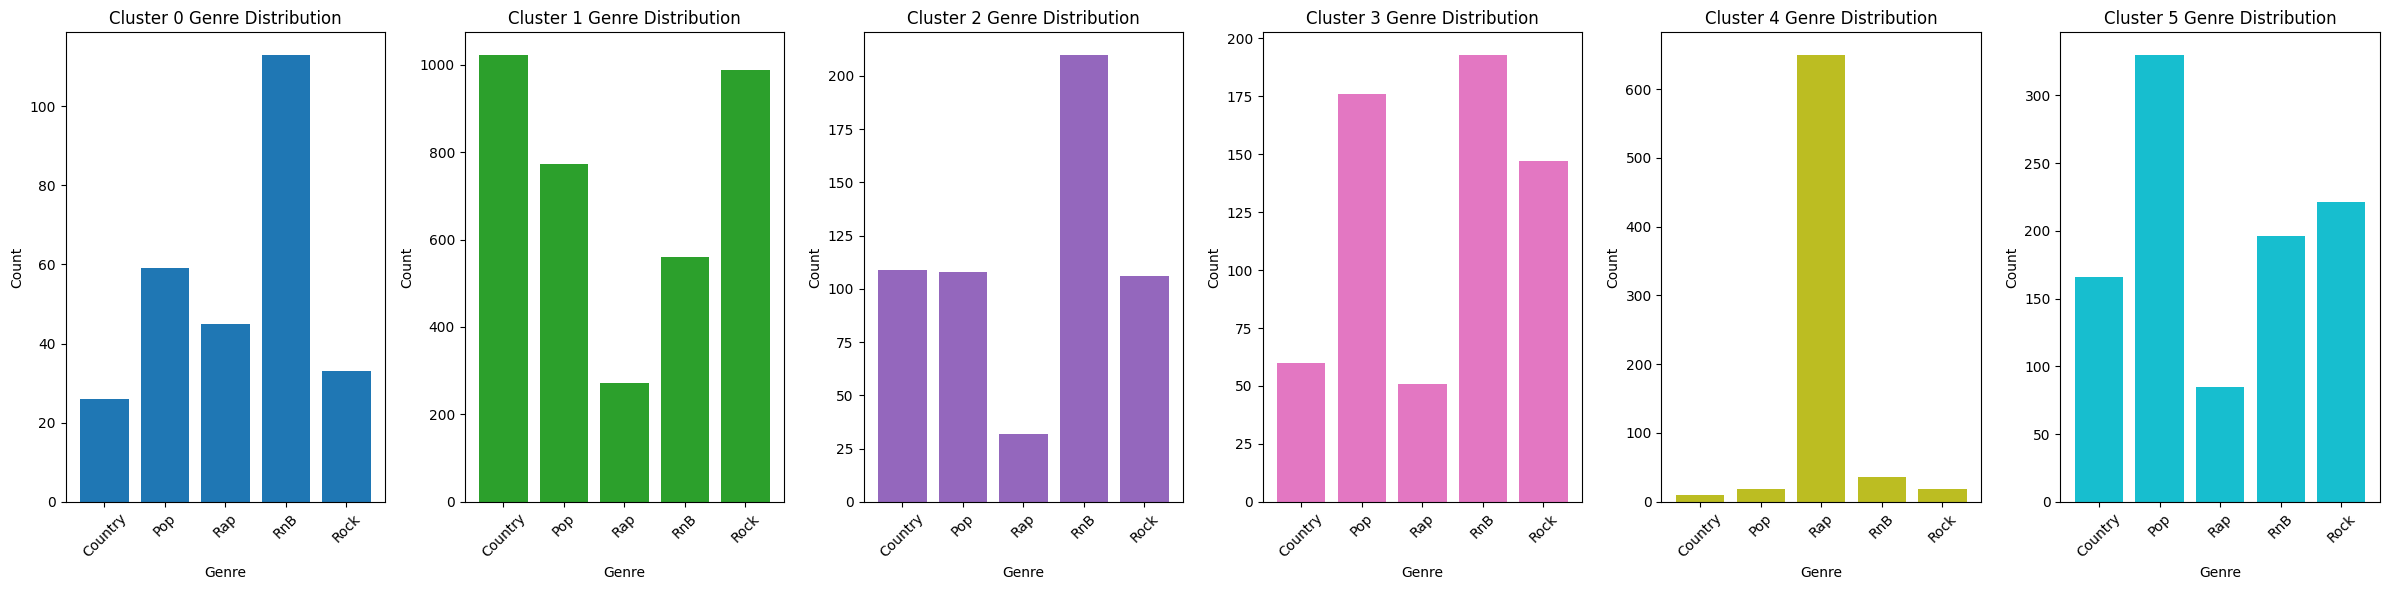

In [14]:
plot_genre_distribution_by_cluster(labels[0], metadata)

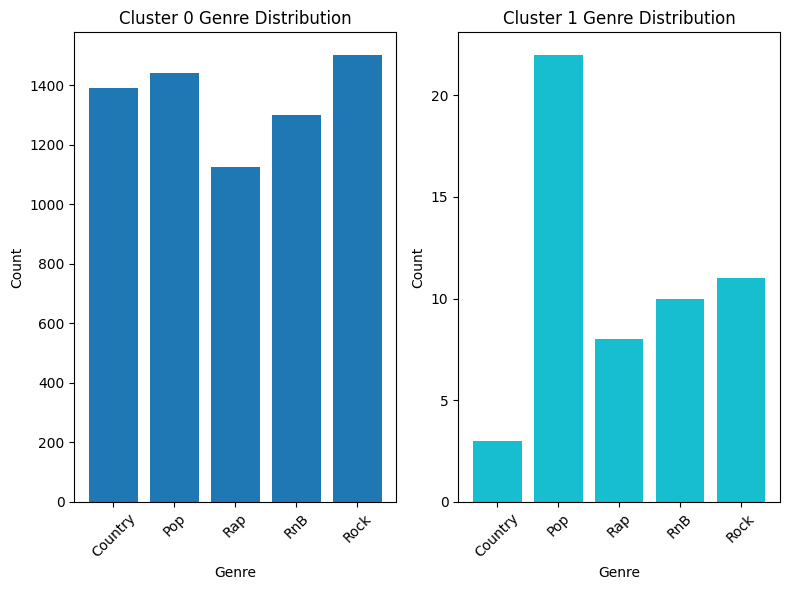

In [15]:
plot_genre_distribution_by_cluster(labels[1], metadata)

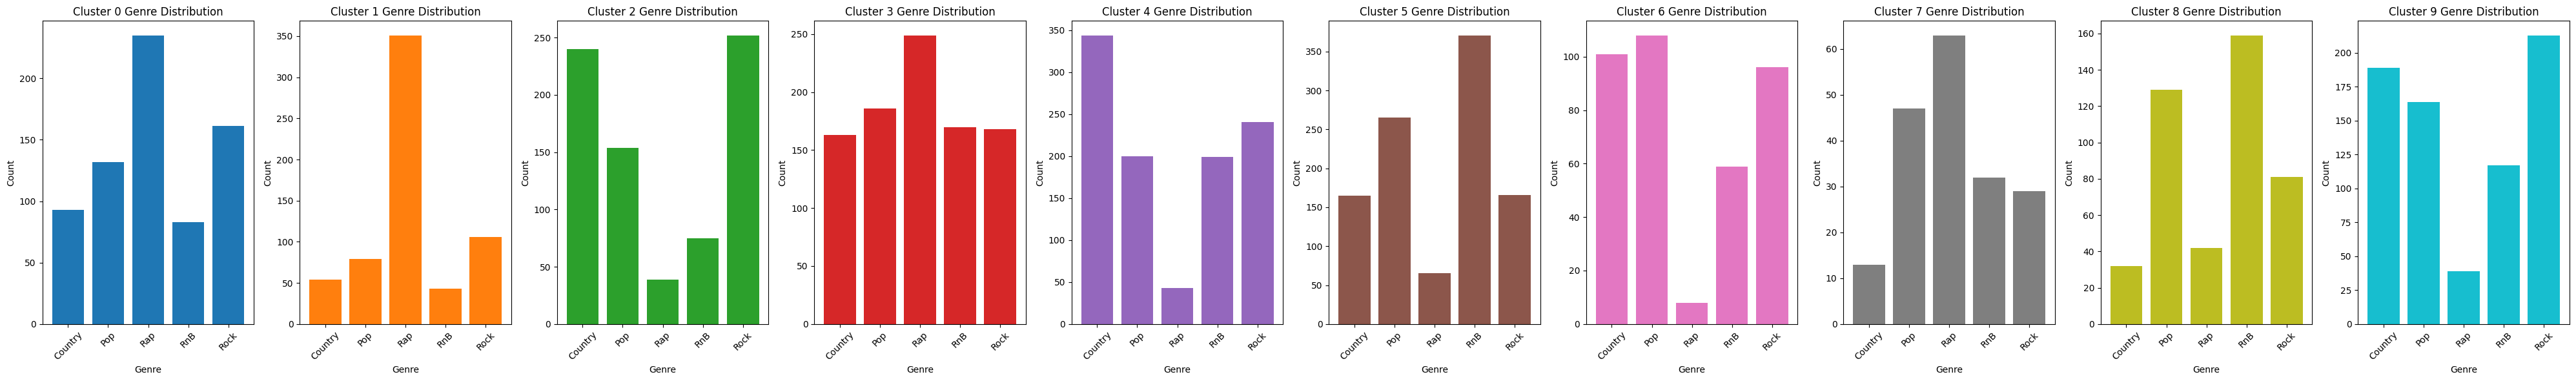

In [16]:
plot_genre_distribution_by_cluster(labels[2], metadata)

ABLATION

In [17]:
scaled_data.head()

,chorus_ratio,syllable_density,sentiment_score,flesch_kincaid_readability,lsa_component_1,lsa_component_2,lsa_component_3,lsa_component_4,lsa_component_5,lsa_component_6,lsa_component_7,lsa_component_8,lsa_component_9,lsa_component_10
0,1.581943,0.924675,0.730768,-1.258854,-0.181727,-0.218021,0.854540,-0.539246,0.391156,0.136847,-1.447807,-0.731282,0.235369,-0.870547
1,1.187036,-0.350646,0.729667,-1.878819,1.046809,-0.902699,-0.574128,0.390248,0.418081,0.346083,0.440494,-0.415330,3.680571,2.338876
2,1.974473,4.410629,0.634108,-1.278728,-1.744547,-0.027111,0.055600,-0.162233,0.019750,-0.056819,0.099490,-0.199752,0.090860,0.002400
3,0.430488,0.596927,0.479330,-0.815929,-1.093905,0.041380,-0.274630,-0.463068,-0.068659,0.094325,-0.365821,-0.203193,-0.222948,0.368619
4,0.682354,-0.234151,0.731013,-1.590681,0.140534,1.938396,-0.960181,0.739948,-1.133738,-0.309909,0.090036,-0.026062,0.004501,-0.348863


In [18]:
kA1,best_silhouettesA1,best_daviesbouldinA1,best_aicA,labelsA1 = cluster_with_best_k(scaled_data.drop(["chorus_ratio","syllable_density","flesch_kincaid_readability"], axis=1))
kA2,best_silhouettesA2,best_daviesbouldinA2,best_aicA2,labelsA2 = cluster_with_best_k(scaled_data.drop(["lsa_component_1","lsa_component_2","lsa_component_3","lsa_component_4","lsa_component_5","lsa_component_6","lsa_component_7","lsa_component_8","lsa_component_9","lsa_component_10","sentiment_score"], axis=1))

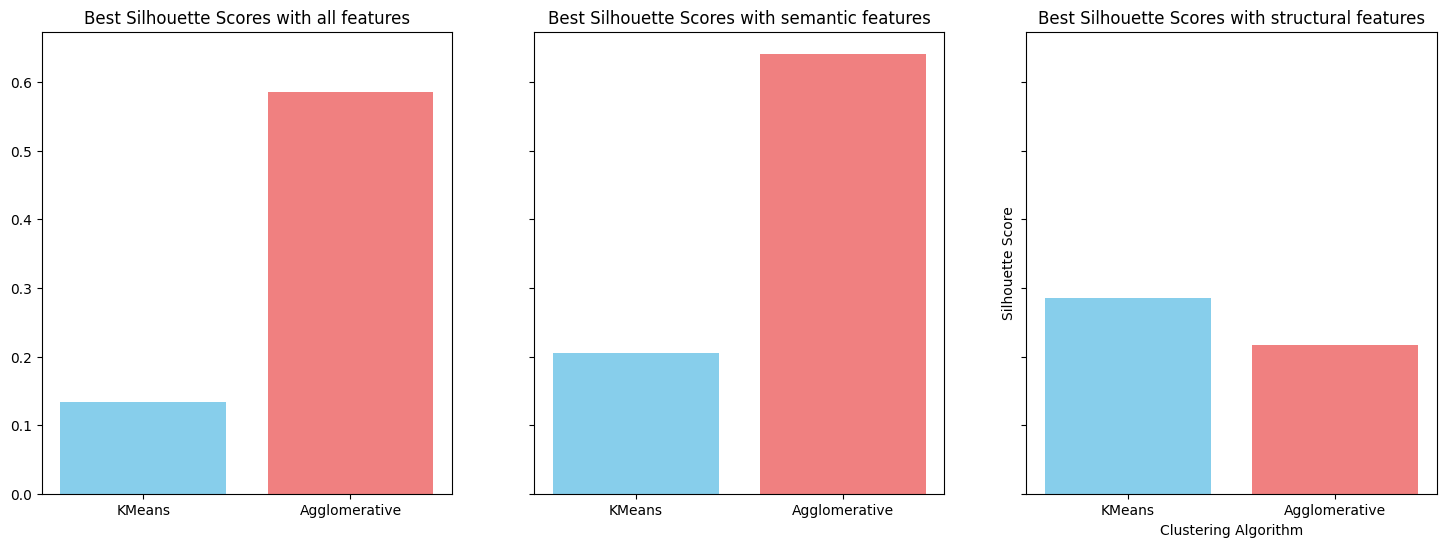

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
barplot = axes[0].bar(['KMeans', 'Agglomerative'], best_silhouettes[:2], color=['skyblue', 'lightcoral'])
axes[0].set_title('Best Silhouette Scores with all features')
barplot = axes[1].bar(['KMeans', 'Agglomerative'], best_silhouettesA1[:2], color=['skyblue', 'lightcoral'])
axes[1].set_title('Best Silhouette Scores with semantic features')
barplot = axes[2].bar(['KMeans', 'Agglomerative'], best_silhouettesA2[:2], color=['skyblue', 'lightcoral'])
axes[2].set_title('Best Silhouette Scores with structural features')
plt.xlabel('Clustering Algorithm')
plt.ylabel('Silhouette Score')
plt.show()

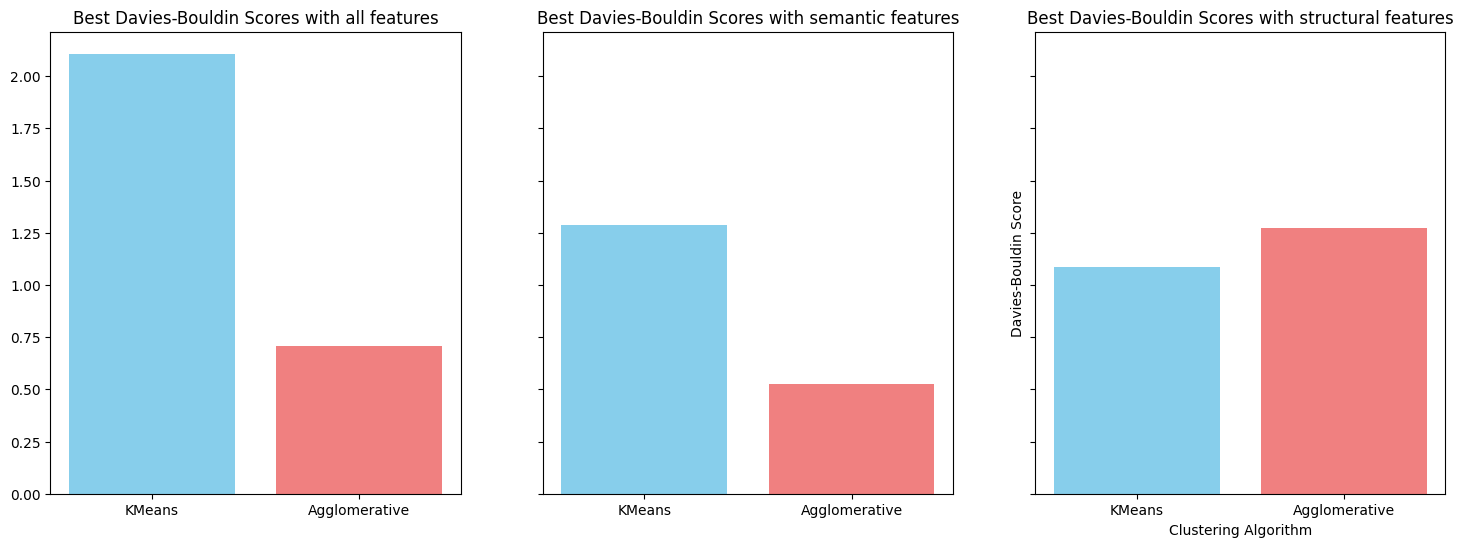

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
barplot = axes[0].bar(['KMeans', 'Agglomerative'], best_daviesbouldin[:2], color=['skyblue', 'lightcoral'])
axes[0].set_title('Best Davies-Bouldin Scores with all features')
barplot = axes[1].bar(['KMeans', 'Agglomerative'], best_daviesbouldinA1[:2], color=['skyblue', 'lightcoral'])
axes[1].set_title('Best Davies-Bouldin Scores with semantic features')
barplot = axes[2].bar(['KMeans', 'Agglomerative'], best_daviesbouldinA2[:2], color=['skyblue', 'lightcoral'])
axes[2].set_title('Best Davies-Bouldin Scores with structural features')
plt.xlabel('Clustering Algorithm')
plt.ylabel('Davies-Bouldin Score')
plt.show()

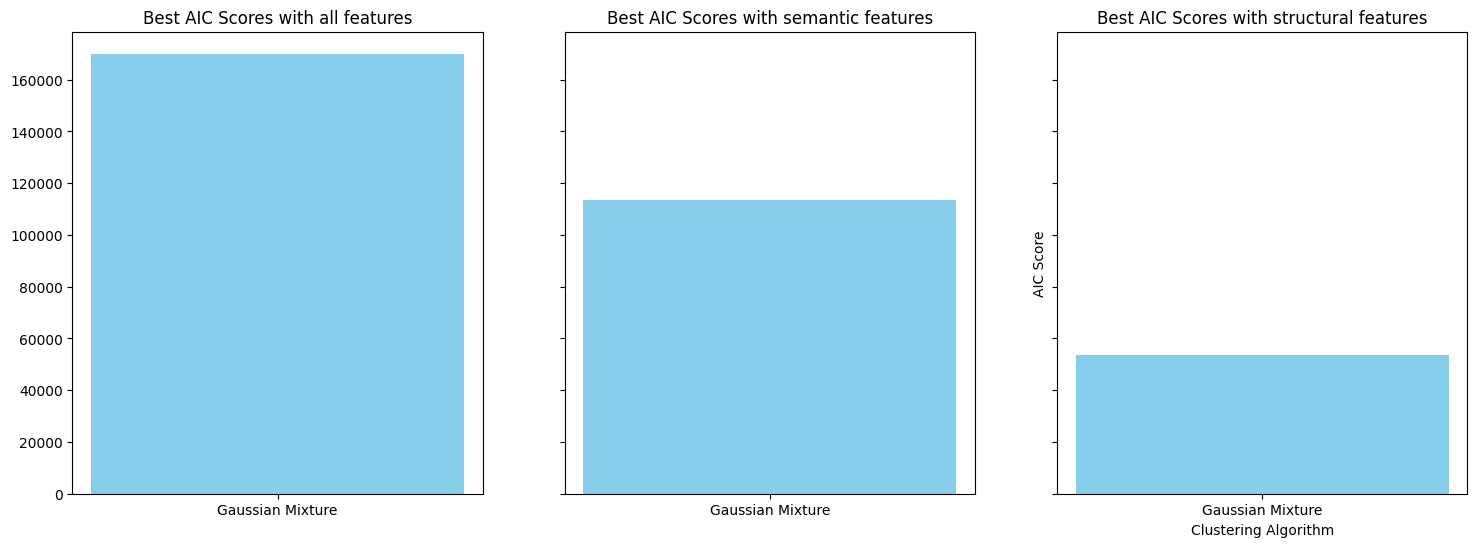

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
barplot = axes[0].bar("Gaussian Mixture", best_aic[2], color=['skyblue', 'lightcoral'])
axes[0].set_title('Best AIC Scores with all features')
barplot = axes[1].bar("Gaussian Mixture", best_aicA[2], color=['skyblue', 'lightcoral'])
axes[1].set_title('Best AIC Scores with semantic features')
barplot = axes[2].bar("Gaussian Mixture", best_aicA2[2], color=['skyblue', 'lightcoral'])
axes[2].set_title('Best AIC Scores with structural features')
plt.xlabel('Clustering Algorithm')
plt.ylabel('AIC Score')
plt.show()

In [22]:
from sklearn.metrics.pairwise import euclidean_distances

def recommend_songs(song_id, data_frame, features_scaled, top_n=5):
    """
    Belirli bir şarkıya benzer şarkıları önerir.
    """

    if song_id not in data_frame['track_id'].values:
        return "Şarkı bulunamadı."
    
    song_idx = data_frame[data_frame['track_id'] == song_id].index[0]
    

    song_cluster = data_frame.loc[song_idx, 'cluster']
    

    cluster_members = data_frame[data_frame['cluster'] == song_cluster]
    cluster_indices = cluster_members.index
    

    target_song_vector = features_scaled[song_idx].reshape(1, -1)
    cluster_vectors = features_scaled[cluster_indices]
    
    distances = euclidean_distances(target_song_vector, cluster_vectors).flatten()
    

    recommendations = pd.DataFrame({
        'track_id': cluster_members['track_id'],
        'artist': cluster_members['artist'],
        'genre': cluster_members['genre'],
        'distance': distances
    })
    

    recommendations = recommendations[recommendations['track_id'] != song_id]
    return recommendations.sort_values(by='distance').head(top_n)

data['cluster'] = labels[0] 
print(recommend_songs('Pop_00001', data, scaled_data.values))

           track_id           artist    genre  distance
4378      RnB_00008       Diana Ross      RnB  1.691540
111       Pop_00112          Rihanna      Pop  1.728080
2884     Rock_01421        Scorpions     Rock  1.803613
735       Pop_00736  Michael Jackson      Pop  1.932655
3413  Country_00437     Garth Brooks  Country  1.942506


=== Fixed 5 Clusters for All Algorithms ===

--- KMeans (5 clusters) ---
0     422
1    3716
2     620
3    1298
4     757
Name: count, dtype: int64


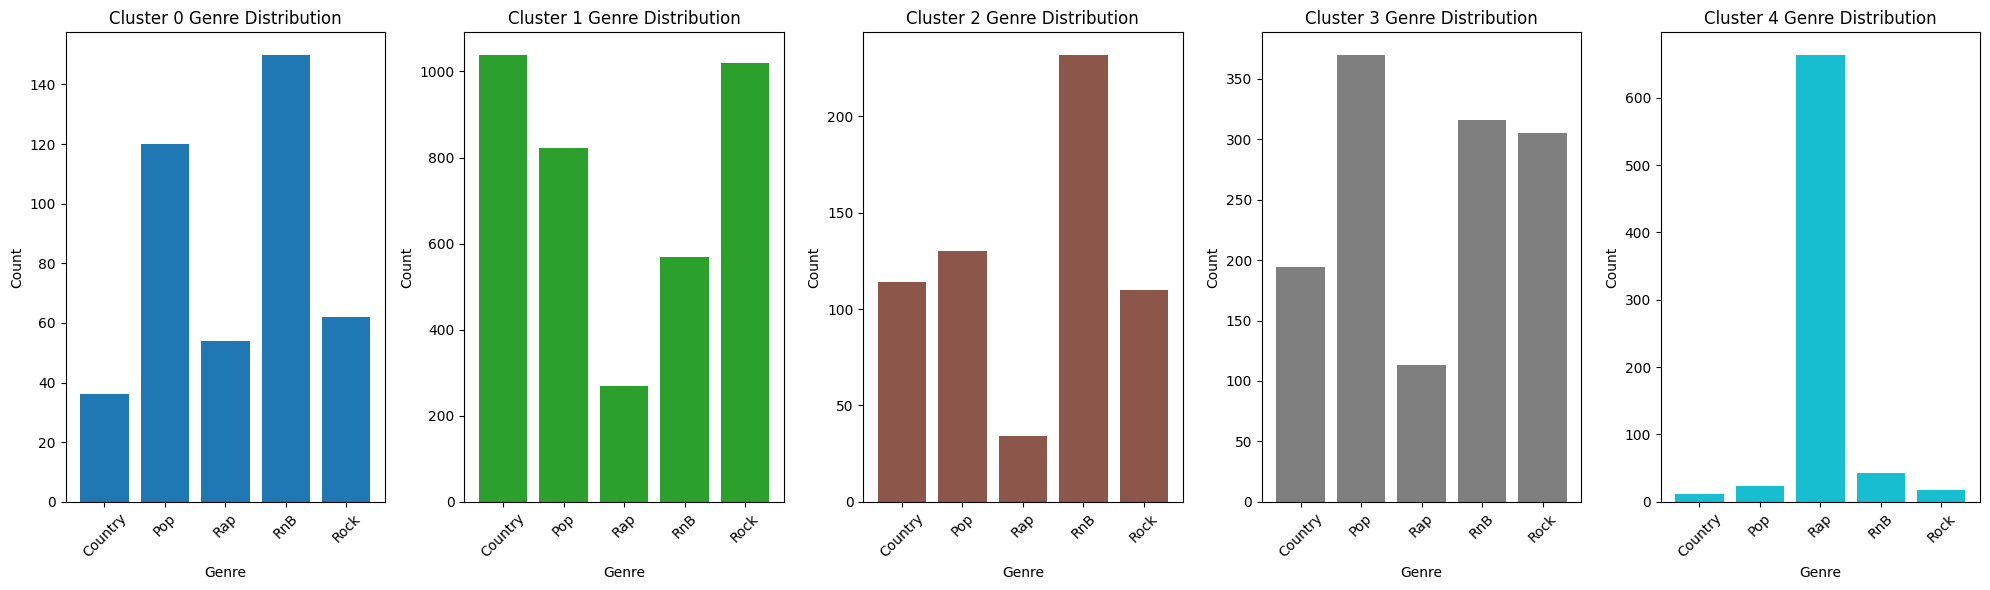


--- Agglomerative (5 clusters) ---
0    4025
1     794
2    1361
3      54
4     579
Name: count, dtype: int64


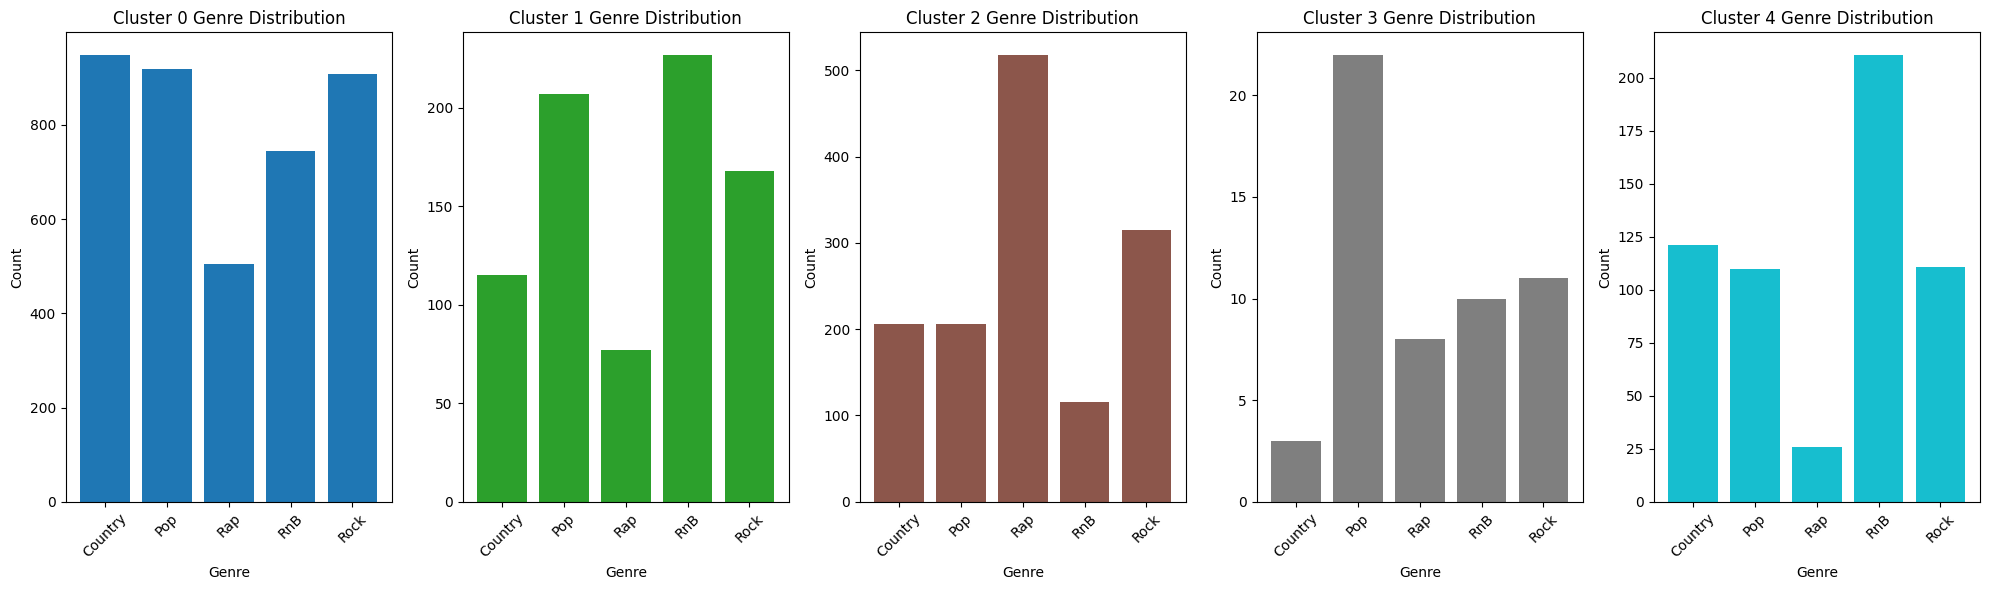


--- GMM (5 clusters) ---
0     470
1     422
2    2193
3    1515
4    2213
Name: count, dtype: int64


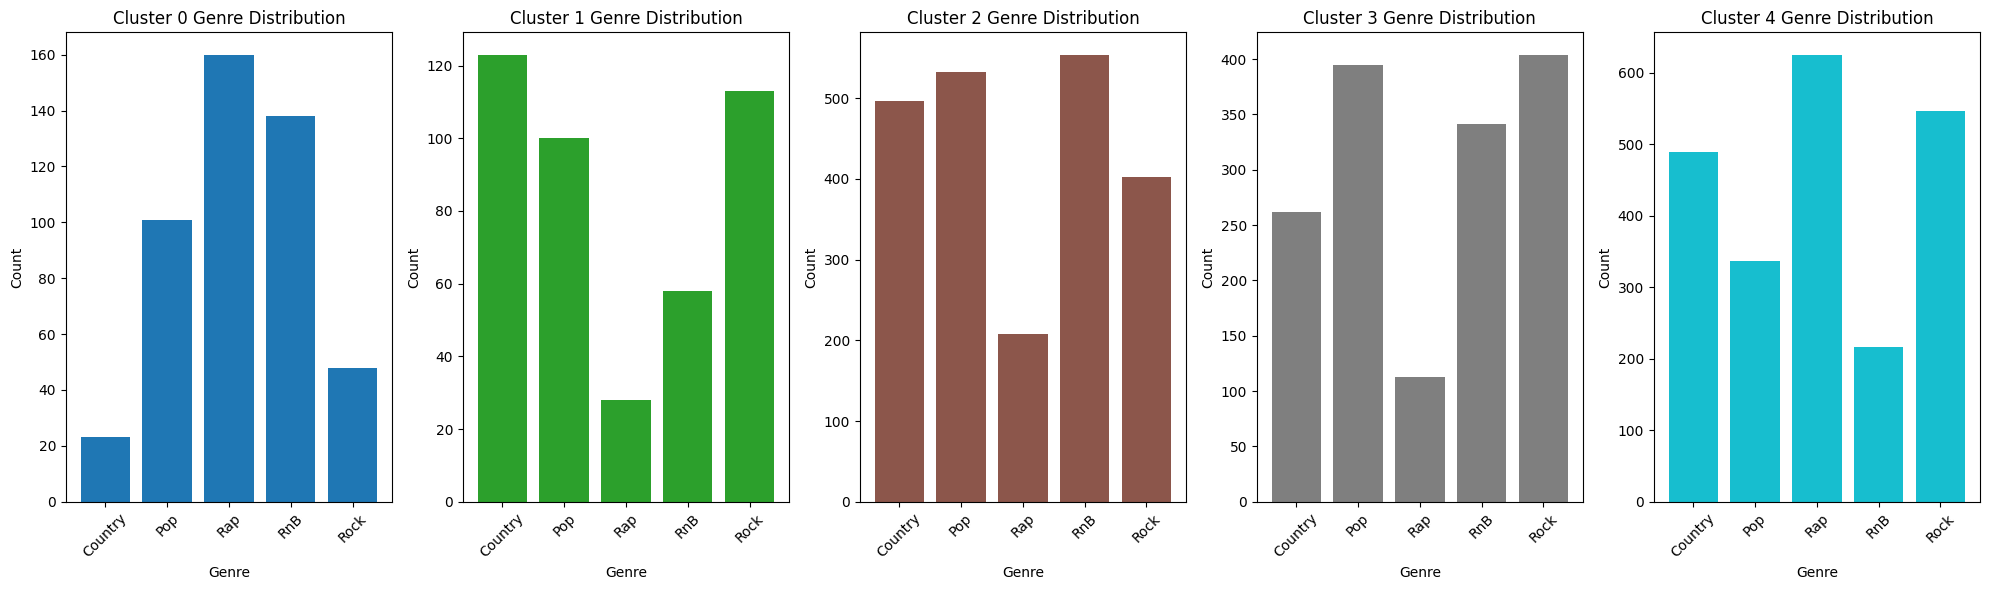


Gaussian Mixture AIC (k=5): 190804.62


In [23]:
# Sabit 5 küme ile mevcut tüm clustering algoritmalarını çalıştır ve sonuçları göster
fixed_k = 5
print(f"=== Fixed {fixed_k} Clusters for All Algorithms ===")

k5, best_silhouettes5, best_daviesbouldin5, best_aic5, labels5 = cluster_with_best_k(scaled_data, min_k=fixed_k, max_k=fixed_k + 1)
algorithms = ['KMeans', 'Agglomerative', 'GMM']

for i, name in enumerate(algorithms):
    labels_fixed = labels5[i]
    print(f"\n--- {name} ({fixed_k} clusters) ---")
    print(pd.Series(labels_fixed).value_counts().sort_index())
    plot_genre_distribution_by_cluster(labels_fixed, metadata)

# GMM için ek olarak AIC değeri de göster
print(f"\nGaussian Mixture AIC (k={fixed_k}): {best_aic5[2]:.2f}")

In [24]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

def evaluate_with_ground_truth(metadata, cluster_labels, method_name):
    """
    Kümeleme sonuçlarını gerçek tür etiketleriyle karşılaştırır.
    """
    # Gerçek tür etiketleri (y_true) ve modelin atadığı kümeler (y_pred)
    y_true = metadata['genre']
    y_pred = cluster_labels
    
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    
    print(f"--- {method_name} Evaluation ---")
    print(f"Adjusted Rand Index (ARI): {ari:.4f}")
    print(f"Normalized Mutual Information (NMI): {nmi:.4f}\n")
    
    return ari, nmi

# Modellerin için hesapla
# labels[0]: K-Means, labels[1]: Agglomerative, labels[2]: GMM (Notebook'undaki sıraya göre)
kmeans_ari, kmeans_nmi = evaluate_with_ground_truth(metadata, labels[0], "K-Means")
agg_ari, agg_nmi = evaluate_with_ground_truth(metadata, labels[1], "Agglomerative")
gmm_ari, gmm_nmi = evaluate_with_ground_truth(metadata, labels[2], "GMM")

--- K-Means Evaluation ---
Adjusted Rand Index (ARI): 0.0806
Normalized Mutual Information (NMI): 0.1321

--- Agglomerative Evaluation ---
Adjusted Rand Index (ARI): -0.0001
Normalized Mutual Information (NMI): 0.0014

--- GMM Evaluation ---
Adjusted Rand Index (ARI): 0.0393
Normalized Mutual Information (NMI): 0.0675



In [25]:
kmeans_ari1, kmeans_nmi1 = evaluate_with_ground_truth(metadata, labelsA1[0], "K-Means (Semantic Features)")
gmm_ari1, gmm_nmi1 = evaluate_with_ground_truth(metadata, labelsA1[2], "GMM (Semantic Features)")
kmeans_ari2, kmeans_nmi2 = evaluate_with_ground_truth(metadata, labelsA2[0], "K-Means (Structural Features)")
gmm_ari2, gmm_nmi2 = evaluate_with_ground_truth(metadata, labelsA2[2], "GMM (Structural Features)")

--- K-Means (Semantic Features) Evaluation ---
Adjusted Rand Index (ARI): 0.0489
Normalized Mutual Information (NMI): 0.0985

--- GMM (Semantic Features) Evaluation ---
Adjusted Rand Index (ARI): 0.0384
Normalized Mutual Information (NMI): 0.0655

--- K-Means (Structural Features) Evaluation ---
Adjusted Rand Index (ARI): 0.0229
Normalized Mutual Information (NMI): 0.0300

--- GMM (Structural Features) Evaluation ---
Adjusted Rand Index (ARI): 0.0256
Normalized Mutual Information (NMI): 0.0394



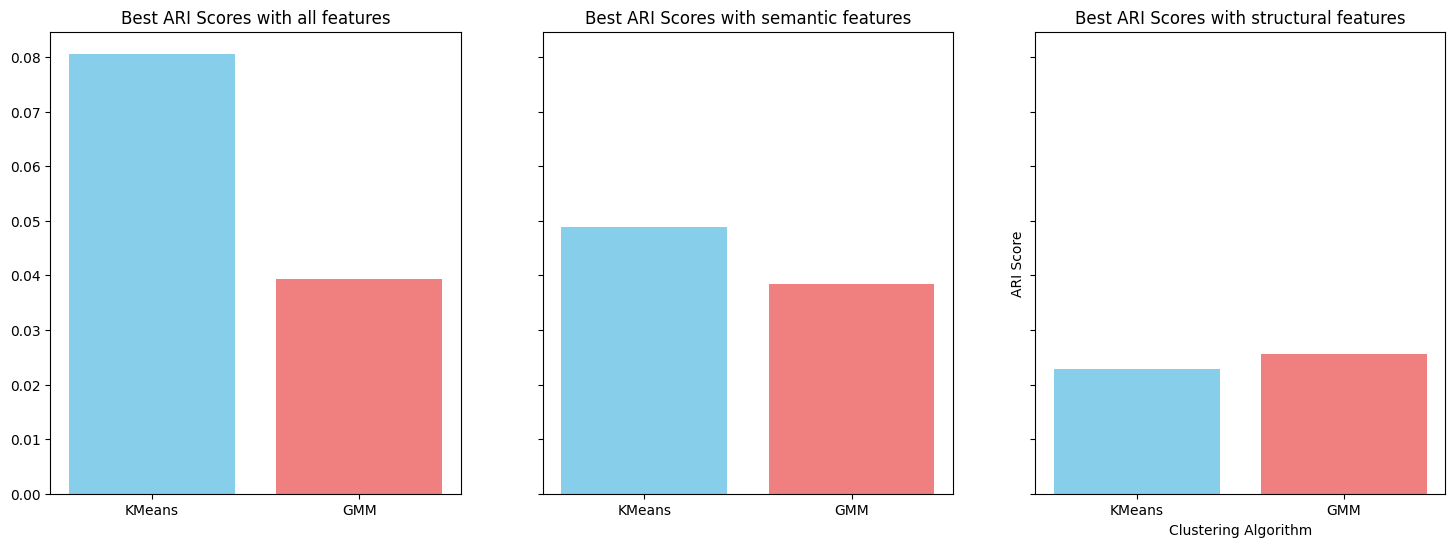

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
barplot = axes[0].bar(['KMeans', 'GMM'], [kmeans_ari, gmm_ari], color=['skyblue', 'lightcoral'])
axes[0].set_title('Best ARI Scores with all features')
barplot = axes[1].bar(['KMeans', 'GMM'], [kmeans_ari1, gmm_ari1], color=['skyblue', 'lightcoral'])
axes[1].set_title('Best ARI Scores with semantic features')
barplot = axes[2].bar(['KMeans', 'GMM'], [kmeans_ari2, gmm_ari2], color=['skyblue', 'lightcoral'])
axes[2].set_title('Best ARI Scores with structural features')
plt.xlabel('Clustering Algorithm')
plt.ylabel('ARI Score')
plt.show()

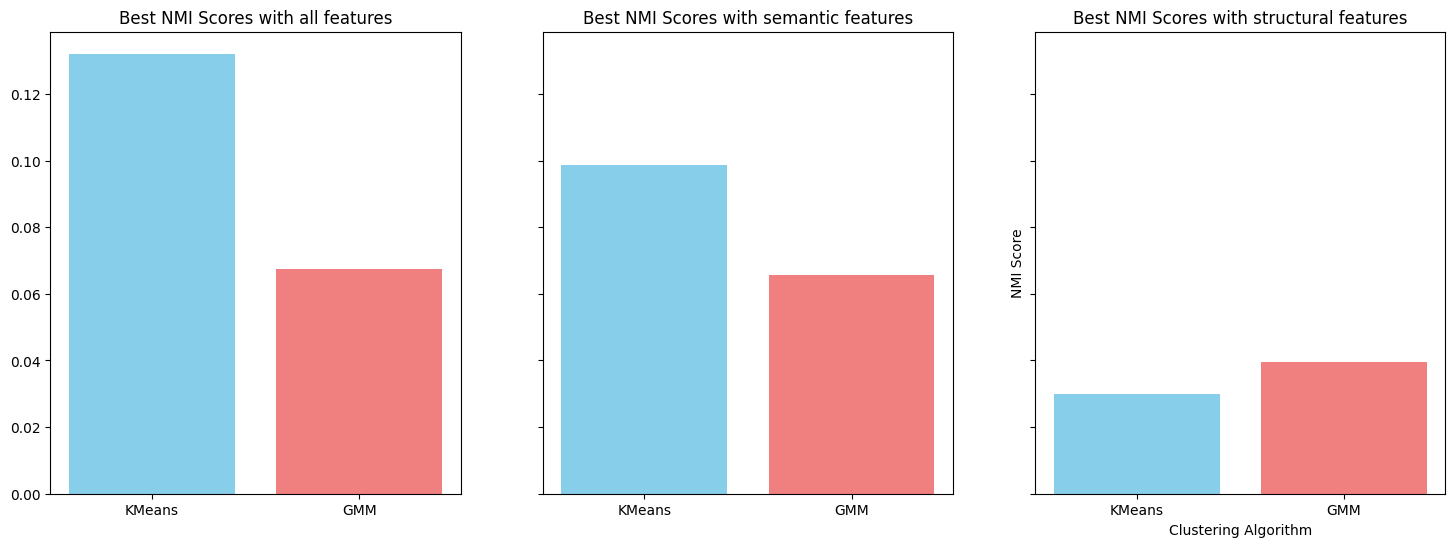

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
barplot = axes[0].bar(['KMeans', 'GMM'], [kmeans_nmi, gmm_nmi], color=['skyblue', 'lightcoral'])
axes[0].set_title('Best NMI Scores with all features')
barplot = axes[1].bar(['KMeans', 'GMM'], [kmeans_nmi1, gmm_nmi1], color=['skyblue', 'lightcoral'])
axes[1].set_title('Best NMI Scores with semantic features')
barplot = axes[2].bar(['KMeans', 'GMM'], [kmeans_nmi2, gmm_nmi2], color=['skyblue', 'lightcoral'])
axes[2].set_title('Best NMI Scores with structural features')
plt.xlabel('Clustering Algorithm')
plt.ylabel('NMI Score')
plt.show()